# Import

In [1]:
import os
import glob
from itertools import product
import numpy as np
import graphical_sampling as gs
import pandas as pd

# NHT Variance

In [27]:
N = 100
n = 4
num_zones = 4
rng = gs.random.rng()
coords = rng.rand_coord((N, 2))
variable = np.random.rand(N) * 10
# inclusions = rng.unequal_inclusions(n, N)
inclusions = variable + np.random.rand(N)
pop = gs.Population(coords, inclusions, n=n, variable=variable)

In [2]:
df = pd.read_csv('populations/MU284_filtered.csv')
cs82 = df['CS82'].values.astype(float)
rmt85 = df['RMT85'].values.astype(float)
ss82 = df['SS82'].values.astype(float)

N = len(df)
n = 10
num_zones = 4
rng = gs.random.rng()
coords = rng.rand_coord((N, 2))
pop = gs.Population(
    coords=rng.rand_coord((N, 2)),
    inclusions=ss82,
    variable=cs82,
    n=4
)

In [3]:
initial_designs = [gs.Design(pop, num_partitions=num_zones) for _ in range(100)]
criteria = gs.criteria.VarNHT()
gbfs = gs.search.GreedyBestFirstSearch(initial_designs, criteria)

In [4]:
gbfs.run(
    max_iterations=1000,
    max_open_set_size=2000,
    top_k=10,
    num_new_order_nodes=0,
    num_new_exchange_nodes=5,
    num_clusters=2,
    num_zones=1,
    num_changes=2,
    num_zone_changes=1,
    random_pull=True,
    exchange_coef=1.0,
    num_explore=5
)

--- Starting Parallel GBFS: Max Iterations=1000, Batch Size=5, Workers=-1 ---
Initial best criteria value: 498813.2237
Iter     0/1000 | Best: 498813.2237 | Open:   100 | Closed:     0
  [!] New best found at iter 0: 493522.1303 (improved by 5291.0934)
  [!] New best found at iter 1: 488712.5256 (improved by 4809.6047)
  [!] New best found at iter 2: 484458.5789 (improved by 4253.9467)
  [!] New best found at iter 2: 483865.2656 (improved by 593.3133)
  [!] New best found at iter 2: 477902.3794 (improved by 5962.8862)
  [!] New best found at iter 3: 477298.6168 (improved by 603.7626)
  [!] New best found at iter 4: 471269.6208 (improved by 6028.9959)
  [!] New best found at iter 4: 470507.9331 (improved by 761.6878)
  [!] New best found at iter 5: 470199.7306 (improved by 308.2025)
  [!] New best found at iter 5: 466570.5962 (improved by 3629.1344)
  [!] New best found at iter 6: 466013.4427 (improved by 557.1535)
  [!] New best found at iter 7: 465103.5046 (improved by 909.9381)
  [!]

# Spread

In [2]:
N = 1000
n = 4
num_zones = 4
rng = gs.random.rng()
coords = rng.rand_coord((N, 2))
variable = np.random.rand(N) * 10
# inclusions = rng.unequal_inclusions(n, N)
inclusions = variable + np.random.rand(N)
pop = gs.Population(coords, inclusions, n=n, variable=variable)

<Axes: title={'center': 'FIP Balanced 4-Means Soft Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

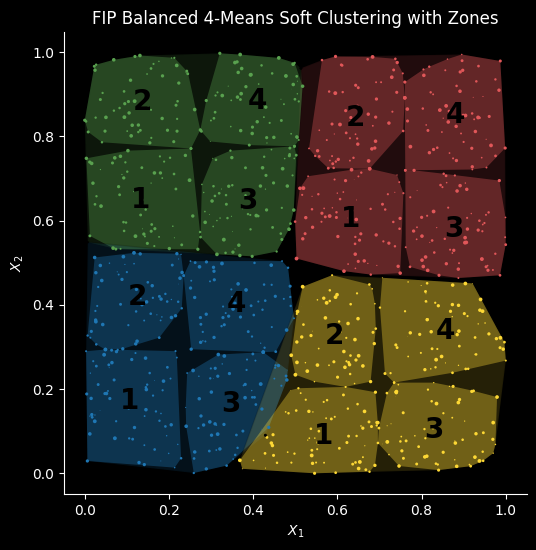

In [3]:
fbn = gs.clustering.FIPBalancedNMeans(n)
fbn.fit(pop)
fbn.fit_zones(num_zones=(2, 2), mode='sweep_xy')
fbn.plot(mode='soft')

In [4]:
design = gs.Design.from_order(pop, gs.Order.from_clusters(pop, fbn.clusters, zone_strategy=None, point_strategy='lexico_xy'))
design.relative_entropy

np.float64(0.26884903645153735)

In [ ]:
order=gs.Order.from_clusters(pop, fbn.clusters, zone_strategy=None, point_strategy='lexico_xy')
fbn.clusters = order.clusters
fbn.plot(mode='soft')

In [ ]:
s = 0
total_share = np.zeros(pop.N)
for cluster in fbn.clusters:
    sc = pop.inclusions[cluster.floor.index] * cluster.floor.percentage
    sc += pop.inclusions[cluster.ceil.index] * cluster.ceil.percentage
    total_share[cluster.floor.index] += cluster.floor.percentage
    total_share[cluster.ceil.index] += cluster.ceil.percentage
    for zone in cluster.zones:
        total_share[zone.indices] += zone.shares
        scz = pop.inclusions[zone.indices] * zone.shares
        print(f'zone sum = {scz.sum().item():.5f}')
        sc += scz.sum().item()
    print(f'cluster sum = {sc:.5f}')
    print()
    s += sc
print(f'total sum = {s:.5f}')
print(total_share)

In [3]:
DATA_DIR = "populations"
csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))

coords_dict = {}
probs_dict = {}

for fp in csv_paths:
    name = os.path.splitext(os.path.basename(fp))[0]
    data = np.loadtxt(fp, delimiter=",", skiprows=1)
    coords = data[:, :2]
    probs  = data[:, -1]

    coord_name, prob_name, *rest = name.split("_")
    coord_name = 'cluster' if coord_name == 'clust' else coord_name
    prob_name = 'equal' if prob_name == 'eq' else 'unequal'

    coords_dict[coord_name] = coords
    probs_dict[coord_name] = probs_dict.get(coord_name, {})
    probs_dict[coord_name][prob_name] = probs

print(coords_dict.keys())

dict_keys(['swiss', 'RegularPop1000', 'AggregatedPop1027', 'cluster', 'meuse', 'random', 'grid', 'MU284'])


In [4]:
coords = coords_dict['random']
probs = probs_dict['random']['unequal']
N = len(probs)
n = 4
num_zones = 4
pop = gs.Population(coords, probs, n=n)

In [19]:
initial_designs = []
point_strategies = [
    None, 'lexico_xy', 'lexico_yx', 'angle', 'dist_from_origin',
    'projection', 'dist_from_centroids', 'max_coord', 'spiral'
]
zone_strategies = [
    None, 'lexico_xy', 'lexico_yx', 'dist_from_origin', 'projection', 'spiral'
]
zone_modes = [
    'cluster', 'sweep_xy', 'sweep_yx'
]
num_zones_cluster = [1, 2, 4]
num_zones_sweep = [(1, 1), (1, 2), (2, 1), (2, 2)]
num_splits = [4]
track = []
for point_strategy, zone_strategy, zone_mode, num_split in product(point_strategies, zone_strategies, zone_modes, num_splits):
    if zone_mode == 'cluster':
        list_of_num_zones = num_zones_cluster
    else:
        list_of_num_zones = num_zones_sweep
    for num_zones in list_of_num_zones:
        for _ in range(1):
            fbn = gs.clustering.FIPBalancedNMeans(n)
            fbn.fit(pop)
            fbn.fit_zones(num_zones=num_zones, mode=zone_mode)
            design = gs.Design.from_order(
                pop,
                order=gs.Order.from_clusters(pop, fbn.clusters, point_strategy, zone_strategy, num_split),
            )
            initial_designs.append(design)
            # print(strategy, zone_mode, num_partitions, design.moran[0])
            track.append((design.moran[0], zone_strategy, point_strategy, zone_mode, num_zones))

In [20]:
z = sorted(track, key=lambda x: x[0], reverse=False)
z
# values = {}
# counter = {}
# for moran, zone_strategy, point_strategy, zone_mode, _ in z:
#     values[(zone_strategy, point_strategy, zone_mode)] = values.get((zone_strategy, point_strategy, zone_mode), 0) + moran
#     counter[(zone_strategy, point_strategy, zone_mode)] = counter.get((zone_strategy, point_strategy, zone_mode), 0) + 1
#
# z2 = []
# for key in values.keys():
#     z2.append((key, values[key]/counter[key]))
# sorted(z2, key=lambda x: x[1], reverse=False)

[(-0.2675383557611679, 'projection', 'spiral', 'sweep_xy', (1, 2)),
 (-0.2644106668352367, 'projection', 'projection', 'sweep_yx', (1, 2)),
 (-0.25931169230821133, 'spiral', 'dist_from_centroids', 'sweep_xy', (1, 2)),
 (-0.2592079812156875, 'lexico_yx', 'spiral', 'sweep_xy', (2, 1)),
 (-0.2592079812156875, 'lexico_yx', 'spiral', 'sweep_yx', (2, 1)),
 (-0.2568364936409671, 'projection', 'projection', 'cluster', 1),
 (-0.2568364936409671, 'projection', 'spiral', 'cluster', 1),
 (-0.2542640968077454, 'lexico_xy', 'dist_from_centroids', 'sweep_xy', (1, 2)),
 (-0.2538065519567004, 'lexico_xy', 'angle', 'sweep_yx', (1, 2)),
 (-0.25340770967677995, 'projection', 'angle', 'sweep_xy', (1, 2)),
 (-0.2494347731908224, 'projection', None, 'cluster', 2),
 (-0.2491474230399439, 'projection', None, 'sweep_yx', (2, 2)),
 (-0.24873265479681184, 'projection', None, 'sweep_yx', (1, 2)),
 (-0.24873265479681184, 'projection', 'lexico_yx', 'sweep_xy', (1, 2)),
 (-0.24873265479681184, 'projection', 'dist_fro

In [19]:
for i, design in enumerate(initial_designs):
    try:
        design.moran
    except:
        for event in design.events:
            print(event)
        break

In [21]:
criteria = gs.criteria.MoranCriteria()
gbfs = gs.search.GreedyBestFirstSearch(initial_designs, criteria)

In [22]:
gbfs.run(
    max_iterations=2000,
    max_open_set_size=1000,
    top_k=1,
    num_new_order_nodes=10,
    num_new_exchange_nodes=0,
    num_clusters=1,
    num_zones=1,
    num_changes=1,
    num_zone_changes=0,
    pull_strategy='default',
    exchange_coef=1.0,
    num_explore=1
)

--- Starting Parallel GBFS: Max Iterations=2000, Batch Size=1, Workers=-1 ---
Initial best criteria value: -0.2675
Iter     0/2000 | Best: -0.2675 | Open:   594 | Closed:     0
  [!] New best found at iter 0: -0.2680 (improved by 0.0004)
  [!] New best found at iter 0: -0.2680 (improved by 0.0000)
  [!] New best found at iter 0: -0.2690 (improved by 0.0010)
  [!] New best found at iter 1: -0.2713 (improved by 0.0022)
  [!] New best found at iter 1: -0.2725 (improved by 0.0013)
  [!] New best found at iter 2: -0.2737 (improved by 0.0011)
  [!] New best found at iter 3: -0.2742 (improved by 0.0005)
  [!] New best found at iter 4: -0.2745 (improved by 0.0004)
  [!] New best found at iter 5: -0.2763 (improved by 0.0018)
  [!] New best found at iter 6: -0.2840 (improved by 0.0077)
  [!] New best found at iter 7: -0.2840 (improved by 0.0000)
  [!] New best found at iter 7: -0.2853 (improved by 0.0013)
  [!] New best found at iter 7: -0.2870 (improved by 0.0017)
  [!] New best found at iter 8

In [ ]:
z1 = [1, 2, 3, 4]
z2 = [5.0, 6.94, 7.3, 8.21]

print(np.column_stack([z1, z2]))

In [ ]:
[99, *z1, 55555]

In [13]:
samples = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16],
])

probs = np.array([0.1, 0.5, 0.2, 0.2])
probs.cumsum()

array([0.1, 0.6, 0.8, 1. ])

In [11]:
rng = np.random.default_rng(42)
a = rng.random(10)
a

array([0.77395605, 0.43887844, 0.85859792, 0.69736803, 0.09417735,
       0.97562235, 0.7611397 , 0.78606431, 0.12811363, 0.45038594])

In [15]:
indices = np.searchsorted(probs.cumsum(), np.array([0.0, 0.05, 0.15, 0.5, 0.65, 0.9, 1.0]))

In [16]:
samples[indices]

array([[ 1,  2,  3,  4],
       [ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [13, 14, 15, 16]])